## 다층 퍼셉트론, 순전파(feedforward) 인공신경망의 전형
1. 순방향 패스
2. 오차 계산
3. 역방향 패스

In [7]:
import numpy as np
from sklearn.linear_model import Perceptron
# %run perceptron.ipynb

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

### 3.0. 활성화 함수

In [3]:
class ActivationFunctions:

    def __init__(self, x):
        self.x = x

    def stepfunctionwithNum(self):
        if self.x > 0.0 : return 1
        else : return 0

    def stepfunctionwithArray(self):
        result = self.x > 0.0
        # True or False 반환
        return result.astype(np.int64)
        # 정수형으로 결과값 반환

    def sigmoidFunction(self):
        """시그모이드 함수
        Logic:
            - 실수 입력값을 0과 1 사이의 값으로 변환
            - 1 / (1 + e**(-x))"""
        return 1.0 + (1.0 + np.exp(-self.x))
        # .backward(self, dx):
            # return (1- self.x) * self.x * dx

    def hyperbolicTangent(self):
        """쌍곡선 탄젠트 함수
        Logic:
            - 입력값을 -1과 1 사이의 값으로 변환
            - (e**x - e**(-x)) / (e**x + e**(-x))
        """
        return (np.exp(self.x) - np.exp(-self.x)) / (np.exp(self.x) + np.exp(-self.x))
        # return np.tanh(self.x)

    def RectifiedLinearunit(self):
        """ReLu 정류된 선형 단위(비선형) 함수
        Logic:
            - 입력값이 0보다 크면 그 값 출력, 0이하일 경우 0을 출력
            - + / -가 반복되는 신호에서 - 흐름 차단
        """
        return np.maximum(self.x, 0)
        # .forward(self):
            # self.x[self.x <= 0] = 0
            # return self.x

        # .backward(self, dx):
            # self.x[self.x > 0] = 1
            # return self.x * dx
    

1.1. MLP의 순방향 패스(Forward pass)
- 입력 신호가 입력층(input layer) 유닛에 가해짐
- 이들 입력 신호가 은닉층(hidden layter)을 통해 출력층(output layer)으로 전파되는 과정

In [4]:
actf = ActivationFunctions(
    x = np.array( [[0,0], [0,1], [1,0], [1,1]] )
)
# SingleLayerPerceptron: .forward()
# Multi(ex. Two)LayerPerceptron: .forward(), .backpropagation()
# Architecture: Input → Dense(Hidden, ActivationFunctions) → Dense(Output, ActivationFunctions)

---

### 3.1. 손실함수(Loss function)

- 신경망에서 학습시킬 때 실제 출력과 원하는 출력(예측) 사이의 오차를 통해 학습 성과 측정 지표
- 평균 제곱 오차(Mean Squared Error) : 예측값과 정답 간 평균 제곱 오차, $E(w) = \frac{1}{2} \ Sigma_i (y_i - t_i)^2$

l층의 i번째 노드에서 나와서 l+1층의 j번째 노드로 들어가는 연결의 가중치 [도착, 출발] 
$\\ w_{j,i}^{(l)}$

이 구조에서 적용되는 활성화 함수는 시그모이드 함수 $\varphi \\
\phi(z) = \frac{1}{1 + e^{-z}}$

**[입력층과 은닉층 사이의 값의 흐름]**

- 가중합 계산 [선형]

$
 z_1^{(2)} = w_{1,1}^{(1)} a_1^{(1)} + w_{1,2}^{(1)} a_2^{(1)} \\
 z_2^{(2)} = w_{2,1}^{(1)} a_1^{(1)} + w_{2,2}^{(1)} a_2^{(1)}$ 

- 시그모이드 함수 통과 [비선형]

$a_1^{(2)} = \phi(z_1^{(2)}) \\
 a_2^{(2)} = \phi(z_2^{(2)})
$

**[은닉층과 출력층 사이의 값의 흐름]**

$z_1^{(3)} = w_{1,1}^{(2)} a_1^{(2)} + w_{1,2}^{(2)} a_2^{(2)} \\
 z_2^{(3)} = w_{2,1}^{(2)} a_1^{(2)} + w_{2,2}^{(2)} a_2^{(2)} \\
 a_1^{(3)} = \phi(z_1^{(3)}) \\
 a_2^{(3)} = \phi(z_2^{(3)})
$

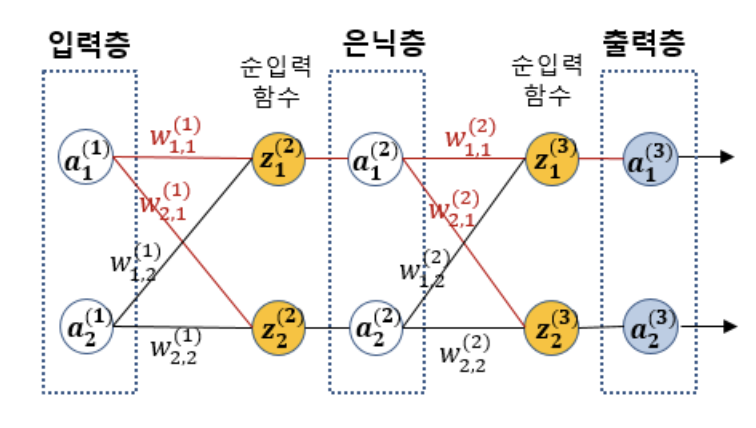

---

### 3.2. 경사하강법(Gradient Descent)

- 예측값과 정답이 차이가 많이 나는 경우 등 
- 손실함수 값을 최소로 하는 가중치를 찾는 목표
- 즉, 신경망 학습 = **최적화(Optimization) 문제**
  - 손실함수를 가중치로 미분한 값이 양수이면, 가중치 감소시킴
  - 손실함수를 가중치로 미분한 값이 음수이면, 가중치 증가시킴

In [1]:
x = 10               # 시작 위치(초기값)
learning_rate = 0.2  # 학습률: 한 번에 이동하는 보폭 (너무 크면 발산, 너무 작으면 느림)
                     # 학습률이 1.0을 넘으면 |1 - 2×lr| > 1이 되어 발산해요.
precision = 0.00001  # 허용 오차: 이동량이 이 값보다 작으면 수렴했다고 판단
max_iterations = 100 # 최대 반복 횟수

loss_function = lambda x: (x - 3)**2 + 10
# 손실함수: f(x) = (x-3)^2 + 10 → x=3일 때 최솟값 10

gradient = lambda x: 2*x - 6
# 손실함수의 1차 미분(기울기): f'(x) = 2(x-3) = 2x - 6

for i in range(max_iterations):
    x -= learning_rate * gradient(x)
    # 학습률 * 기울기만큼 이동
    # 기울기의 반대 방향(내리막)으로 이동
    print("손실함수값(", x, ")=", loss_function(x))

    # if abs( learning_rate * gradient(x) ) < precision:
        # 조기 종료 조건
        # break


print("최소값 = ", x) 
# 최소값 =  3.0000000000000004
# 최종 x (3에 가까워짐)

손실함수값( 7.199999999999999 )= 27.639999999999993
손실함수값( 5.52 )= 16.350399999999997
손실함수값( 4.512 )= 12.286143999999998
손실함수값( 3.9071999999999996 )= 10.82301184
손실함수값( 3.54432 )= 10.2962842624
손실함수값( 3.3265919999999998 )= 10.106662334464
손실함수값( 3.1959551999999998 )= 10.03839844040704
손실함수값( 3.11757312 )= 10.013823438546535
손실함수값( 3.070543872 )= 10.004976437876753
손실함수값( 3.0423263232 )= 10.001791517635631
손실함수값( 3.02539579392 )= 10.000644946348826
손실함수값( 3.015237476352 )= 10.000232180685577
손실함수값( 3.0091424858112 )= 10.000083585046807
손실함수값( 3.00548549148672 )= 10.000030090616852
손실함수값( 3.003291294892032 )= 10.000010832622067
손실함수값( 3.0019747769352194 )= 10.000003899743945
손실함수값( 3.0011848661611316 )= 10.00000140390782
손실함수값( 3.000710919696679 )= 10.000000505406815
손실함수값( 3.0004265518180073 )= 10.000000181946453
손실함수값( 3.0002559310908046 )= 10.000000065500723
손실함수값( 3.0001535586544827 )= 10.00000002358026
손실함수값( 3.0000921351926895 )= 10.000000008488893
손실함수값( 3.0000552811156136 )= 10.000000

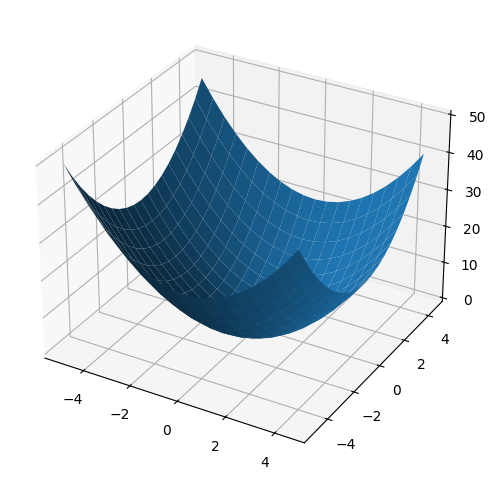

In [16]:
x_arange = np.arange(-5, 5, 0.5) 
y_arange = np.arange(-5, 5, 0.5)
# x, y축 범위: -5 ~ 4.5, 간격 0.5

X, Y = np.meshgrid(x_arange, y_arange)
Z = X**2 + Y**2
# 3D 곡면 시각화: Z = X^2 + Y^2

fig = plt.figure(figsize = (6, 6))
ax = fig.add_subplot(111, projection = "3d")

ax.plot_surface(X, Y, Z)
plt.show()

### 3.3. 역전파 알고리즘(Back-propagation)

- 입력이 주어지며 순방향으로 계산하여 출력을 계산함
- 실제 출력과 우리가 원하는 출력 간의 오차를 계산함
  - 입력층과 출력청 사이에 은닉층의 출력값에 대한 기준값을 정의할 수 없으므로, 
  - 은닉층에서 어떤 값이 출력되어야 맞다, 틀리다하는 기준이 없음
  - 따라서 출력층에서 발생하는 오차값에 따라 역방향으로 오차를 전파시키면서 각 은닉층의 가중치를 업데이트
- 이 오차를 역방향으로 전파하면서 오차를 줄이는 방향으로 가중치 변경

어떤 가중치를 얼마나 바꿔야 오차가 줄어들지, 즉 가중치 $w_{1,1}^{(2)}$를 살짝 늘리면 오차 $E$는 늘어날지 줄어들지 수학적으로 구하는 미분(기울기, gradient)
$\\ \frac{\partial E}{\partial w_{1,1}^{(2)}}$

**[출력이 오차에 미치는 영향] E를 a로 미분**

$E \to a^{(3)} \to z^{(3)} \to w^{(2)}$

$\frac{\partial E}{\partial w_{1,1}^{(2)}} = \frac{\partial E}{\partial a_1^{(3)}} \times \frac{\partial a_1^{(3)}}{\partial z_1^{(3)}} \times \frac{\partial z_1^{(3)}}{\partial w_{1,1}^{(2)}}$

**[가중치 업데이트] $\eta$(에타)는 학습률**

$w_{1,1}^{(2)} \leftarrow w_{1,1}^{(2)} - \eta \times \frac{\partial E}{\partial w_{1,1}^{(2)}}$

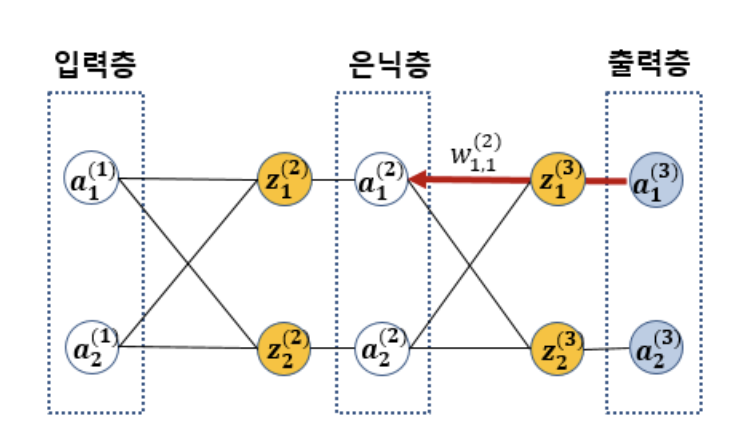
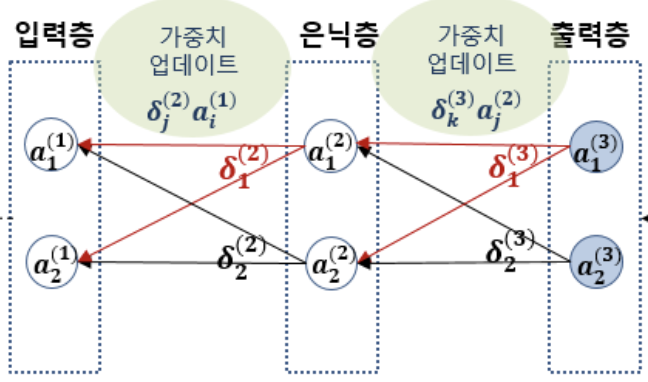

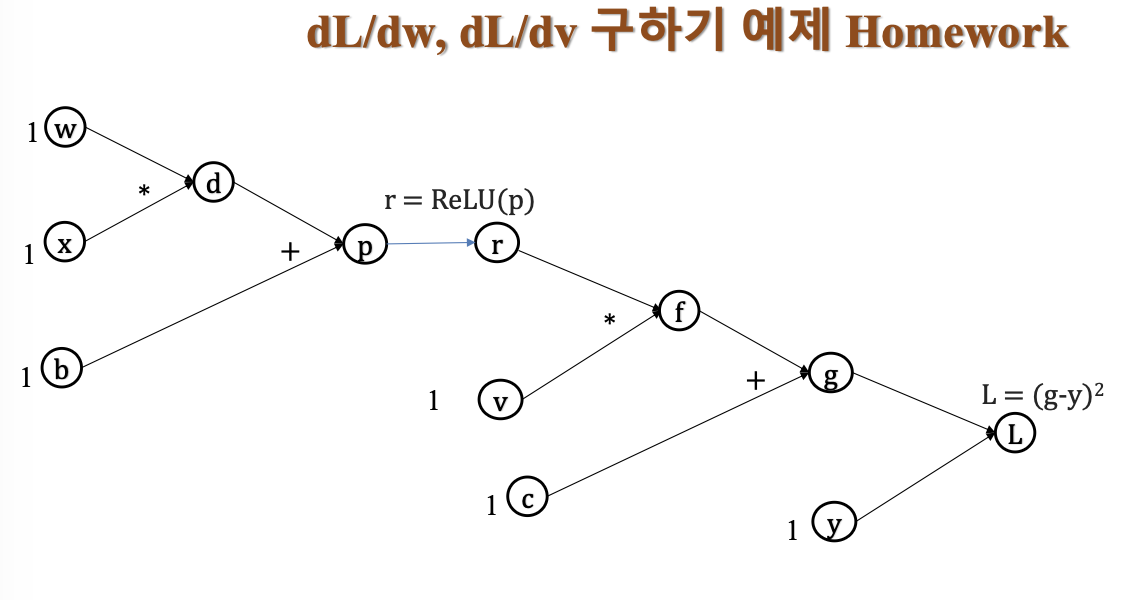